# AutoEncoder : compression, espace latent et generation

In [1]:
from src.dataset import load_mnist_dataset, load_shapes_npz
from src.autoencoder import AutoEncoder
from src.helper import extract_full_dataset, get_device
from src.metrics import compression_report, Latent

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

print("device:", get_device())


EPOCHS = 40
EPOCHS_SWEEP = 40
BATCH_SIZE = 128

device: cpu


In [ ]:
def flattened_vector_to_image(flat_vector, image_shape):
    channels, height, width = image_shape
    image = flat_vector.reshape(channels, height, width)
    return image[0] if channels == 1 else np.transpose(image, (1, 2, 0))

def describe_autoencoder(model, n_train=None, omit=(), extra=None):
    linears = [layer for layer in model.encoder.net if isinstance(layer, nn.Linear)]
    sizes = [linears[0].in_features] + [layer.out_features for layer in linears]
    # L'activation cachee est cherchee UNIQUEMENT avant le dernier Linear: sinon une
    # latent_activation, ajoutee en fin d'encodeur, serait prise pour une activation cachee.
    last_linear = max(i for i, layer in enumerate(model.encoder.net) if isinstance(layer, nn.Linear))
    activation = next((type(layer).__name__ for layer in list(model.encoder.net)[:last_linear]
                       if not isinstance(layer, nn.Linear)), "aucune")
    fields = {
        "couches": "-".join(str(size) for size in sizes),
        "act": activation,
        "latent_act": model.latent_activation.__name__ if model.latent_activation else "aucune",
        "out_act": model.output_activation.__name__ if model.output_activation else "aucune",
        "loss": model.fonction_loss.__name__,
        "epochs": str(len(model.loss_history)),
    }
    if n_train is not None:
        fields["n_train"] = f"{n_train:,}"
    parts = [f"{key}={value}" for key, value in fields.items() if key not in omit]
    if extra:
        parts.append(extra)
    return "fixe: " + " | ".join(parts)

def _finish_figure(fig, title=None, config=None, layout=True):
    if title:
        fig.suptitle(title)
    if config:
        fig.supxlabel(config, fontsize=7.5, color="0.45")
    if layout:
        fig.tight_layout()
    plt.show()

def show_original_vs_reconstruction_grid(originals, reconstructions, image_shape, n=8, title=None, config=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(2, n, figsize=(n * 1.3, 3.2))
    for i in range(n):
        axes[0, i].imshow(flattened_vector_to_image(originals[i], image_shape), cmap=cmap)
        axes[1, i].imshow(np.clip(flattened_vector_to_image(reconstructions[i], image_shape), 0, 1), cmap=cmap)
        for row in (0, 1):
            axes[row, i].set_xticks([]); axes[row, i].set_yticks([])
    axes[0, 0].set_ylabel("original"); axes[1, 0].set_ylabel("reconstruit")
    _finish_figure(fig, title, config)

def show_image_grid(flat_images, image_shape, nrow=4, ncol=8, title=None, config=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 1.1, nrow * 1.1 + 0.6))
    for i, ax in enumerate(np.atleast_1d(axes).ravel()):
        ax.axis("off")
        if i < len(flat_images):
            ax.imshow(np.clip(flattened_vector_to_image(flat_images[i], image_shape), 0, 1), cmap=cmap)
    _finish_figure(fig, title, config)

def show_labeled_image_rows(rows, image_shape, row_labels, n=8, title=None, config=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(len(rows), n, figsize=(n * 1.3, len(rows) * 1.45))
    axes = np.atleast_2d(axes)
    for row_index, (images, label) in enumerate(zip(rows, row_labels)):
        for col in range(n):
            ax = axes[row_index, col]
            ax.set_xticks([]); ax.set_yticks([])
            if col < len(images):
                ax.imshow(np.clip(flattened_vector_to_image(images[col], image_shape), 0, 1), cmap=cmap)
        axes[row_index, 0].set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)
    _finish_figure(fig, title, config)

def plot_latent_scatter(latent_2d, labels, class_names=None, title=None, config=None):
    fig = plt.figure(figsize=(6, 5))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap="tab10", s=6, alpha=0.6)
    if class_names is not None:
        handles, _ = scatter.legend_elements()
        plt.legend(handles, class_names, title="classe", bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        plt.colorbar(scatter, label="chiffre")
    plt.xlabel("z1"); plt.ylabel("z2")
    _finish_figure(fig, title, config)

def print_compression_report(report):
    for key, value in report.items():
        print(f"{key:>24}: {value:,.4f}" if isinstance(value, float) else f"{key:>24}: {value}")

def sample_gaussian_latent(latent_codes, n_samples, seed=0):
    rng = np.random.default_rng(seed)
    mean = latent_codes.mean(axis=0)
    cov = np.cov(latent_codes, rowvar=False)
    return rng.multivariate_normal(mean, cov, size=n_samples).astype(np.float32)

def generate_from_latent_using_gaussian(model, latent, n_samples, seed=0):
    codes = sample_gaussian_latent(latent.array, n_samples, seed=seed)
    return model.decode(Latent(array=codes, nature="continuous"))

def interpolate_latent(z_start, z_end, steps=10):
    alphas = np.linspace(0, 1, steps)[:, None]
    return ((1 - alphas) * z_start[None, :] + alphas * z_end[None, :]).astype(np.float32)

def run_autoencoder_hyperparam_experiment(
        X_train, X_eval, input_dim, latent_dim, activation, epochs, loss_function=nn.MSELoss,
        latent_activation=None, output_activation=nn.Sigmoid
        ):
    model = AutoEncoder(
        input_dim=input_dim, output_dim=input_dim, latent_dim=latent_dim,
        encoder_layer_num=3, decoder_layer_num=3, encoder_activation=activation,
        fonction_loss=loss_function,
        latent_activation=latent_activation, output_activation=output_activation
    )
    model.fit(X_train, epochs=epochs, batch_size=BATCH_SIZE)
    latent = model.encode(X_eval)
    reconstruction = model.decode(latent)
    report = compression_report(model.get_codebook(), latent, X_eval, reconstruction)
    return {"model": model, "latent": latent, "reconstruction": reconstruction, "report": report}

def subsample_dataset(images, labels, n, seed=0):
    if n >= len(images):
        return images, labels
    idx = np.random.default_rng(seed).choice(len(images), size=n, replace=False)
    return images[idx], labels[idx]

## Partie A - MNIST DIGITS

In [3]:
mnist_train_images, mnist_train_labels = extract_full_dataset(load_mnist_dataset(train=True, shuffle=False))
mnist_eval_images, mnist_eval_labels = extract_full_dataset(load_mnist_dataset(train=False, shuffle=False))

MNIST_SHAPE = (1, 28, 28)
X_mnist_train, y_mnist_train = subsample_dataset(
    mnist_train_images.reshape(len(mnist_train_images), -1).numpy(), mnist_train_labels.numpy(), 15000
    )
X_mnist_eval, y_mnist_eval = subsample_dataset(
    mnist_eval_images.reshape(len(mnist_eval_images), -1).numpy(), mnist_eval_labels.numpy(), 3000
    )
print("train:", X_mnist_train.shape, "| eval:", X_mnist_eval.shape)

train: (15000, 784) | eval: (3000, 784)


### Train - ReLu et MSE comme baseline

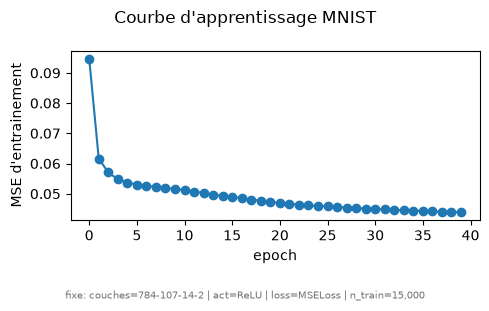

In [4]:
mnist_model = AutoEncoder(
    input_dim=784, output_dim=784, latent_dim=2,
    encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU, fonction_loss=nn.MSELoss
)
mnist_model.fit(X_mnist_train, epochs=EPOCHS, batch_size=BATCH_SIZE)

MNIST_BASELINE_CONFIG = describe_autoencoder(mnist_model, n_train=len(X_mnist_train))

fig = plt.figure(figsize=(5, 3))
plt.plot(mnist_model.loss_history, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE d'entrainement")
# epochs varie le long de l'axe x: on le retire de la note
_finish_figure(fig, "Courbe d'apprentissage MNIST",
               describe_autoencoder(mnist_model, n_train=len(X_mnist_train), omit=("epochs",)))

### Compression et decompression

code latent par image: 2 valeurs | nature: continuous


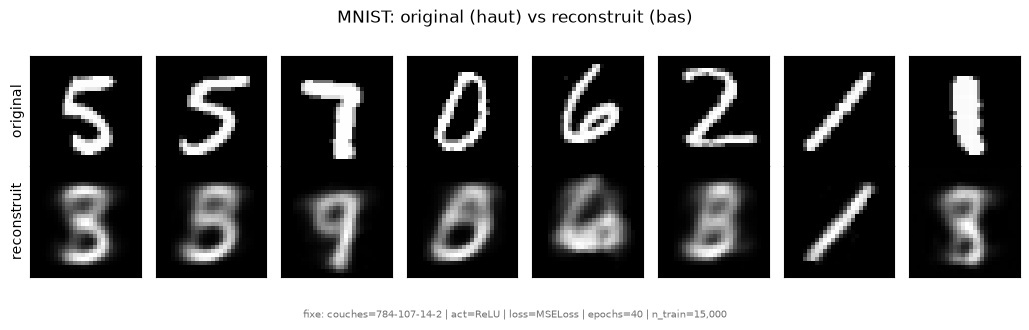

In [5]:
mnist_latent = mnist_model.encode(X_mnist_eval)
mnist_reconstructed = mnist_model.decode(mnist_latent)
print("code latent par image:", mnist_latent.array.shape[1], "valeurs | nature:", mnist_latent.nature)
show_original_vs_reconstruction_grid(X_mnist_eval, mnist_reconstructed, MNIST_SHAPE, n=8,
                     title="MNIST: original (haut) vs reconstruit (bas)",
                     config=MNIST_BASELINE_CONFIG)

### Qualite de reconstruction et taille du message

In [6]:
mnist_report = compression_report(mnist_model.get_codebook(), mnist_latent, X_mnist_eval, mnist_reconstructed)
print_compression_report(mnist_report)

per_image_bytes = mnist_latent.n_bytes / len(X_mnist_eval)
print(f"\nMessage transmis par image: {per_image_bytes:.0f} octets ({mnist_latent.array.shape[1]} float32),")
print(f"contre {X_mnist_eval[0].nbytes} octets pour l'image originale en float32.")
print(f"Codebook (poids du decodeur): {mnist_report['codebook_bytes']:,} octets, partage une seule fois.")

           latent_nature: continuous
          codebook_bytes: 345276
            latent_bytes: 24000
  total_compressed_bytes: 369276
          original_bytes: 9408000
       compression_ratio: 25.4769
      reconstruction_mse: 0.0439

Message transmis par image: 8 octets (2 float32),
contre 3136 octets pour l'image originale en float32.
Codebook (poids du decodeur): 345,276 octets, partage une seule fois.


### Visualisation de l'espace latent

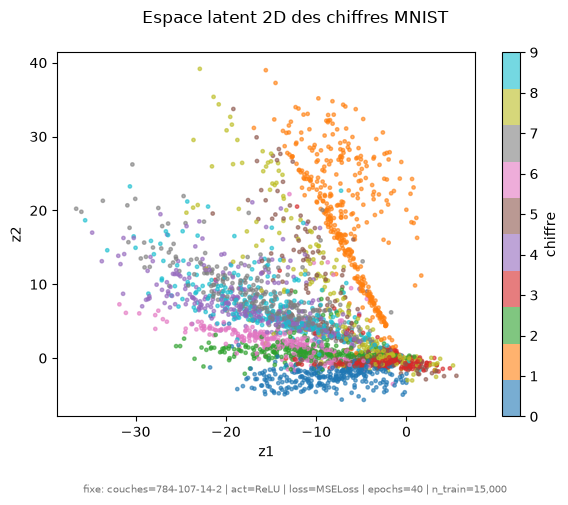

In [7]:
plot_latent_scatter(mnist_latent.array, y_mnist_eval,
                    title="Espace latent 2D des chiffres MNIST",
                    config=MNIST_BASELINE_CONFIG)

### Generation de nouvelles images

Le decodeur seul est un generateur: on lui fournit des codes latents inedits.

- Echantillonnage gaussien: on ajuste une gaussienne sur les codes du jeu d'evaluation et on en tire de nouveaux.
- Interpolation: on relie deux images reelles par une droite dans l'espace latent.
- Balayage de la variete 2D: on decode une grille reguliere du plan latent du modele 2D.

Note: un AutoEncoder classique ne contraint pas son espace latent a une loi connue; rester pres de la distribution des donnees (gaussienne ajustee, interpolation) donne les images les plus nettes.

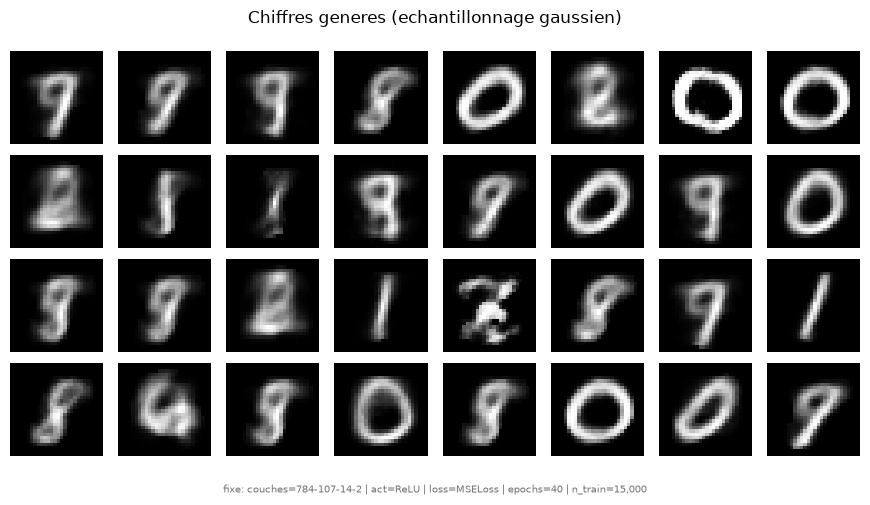

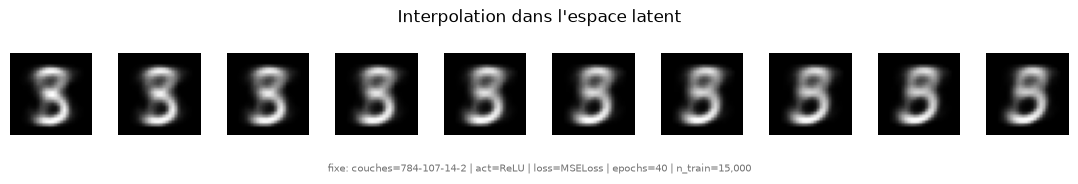

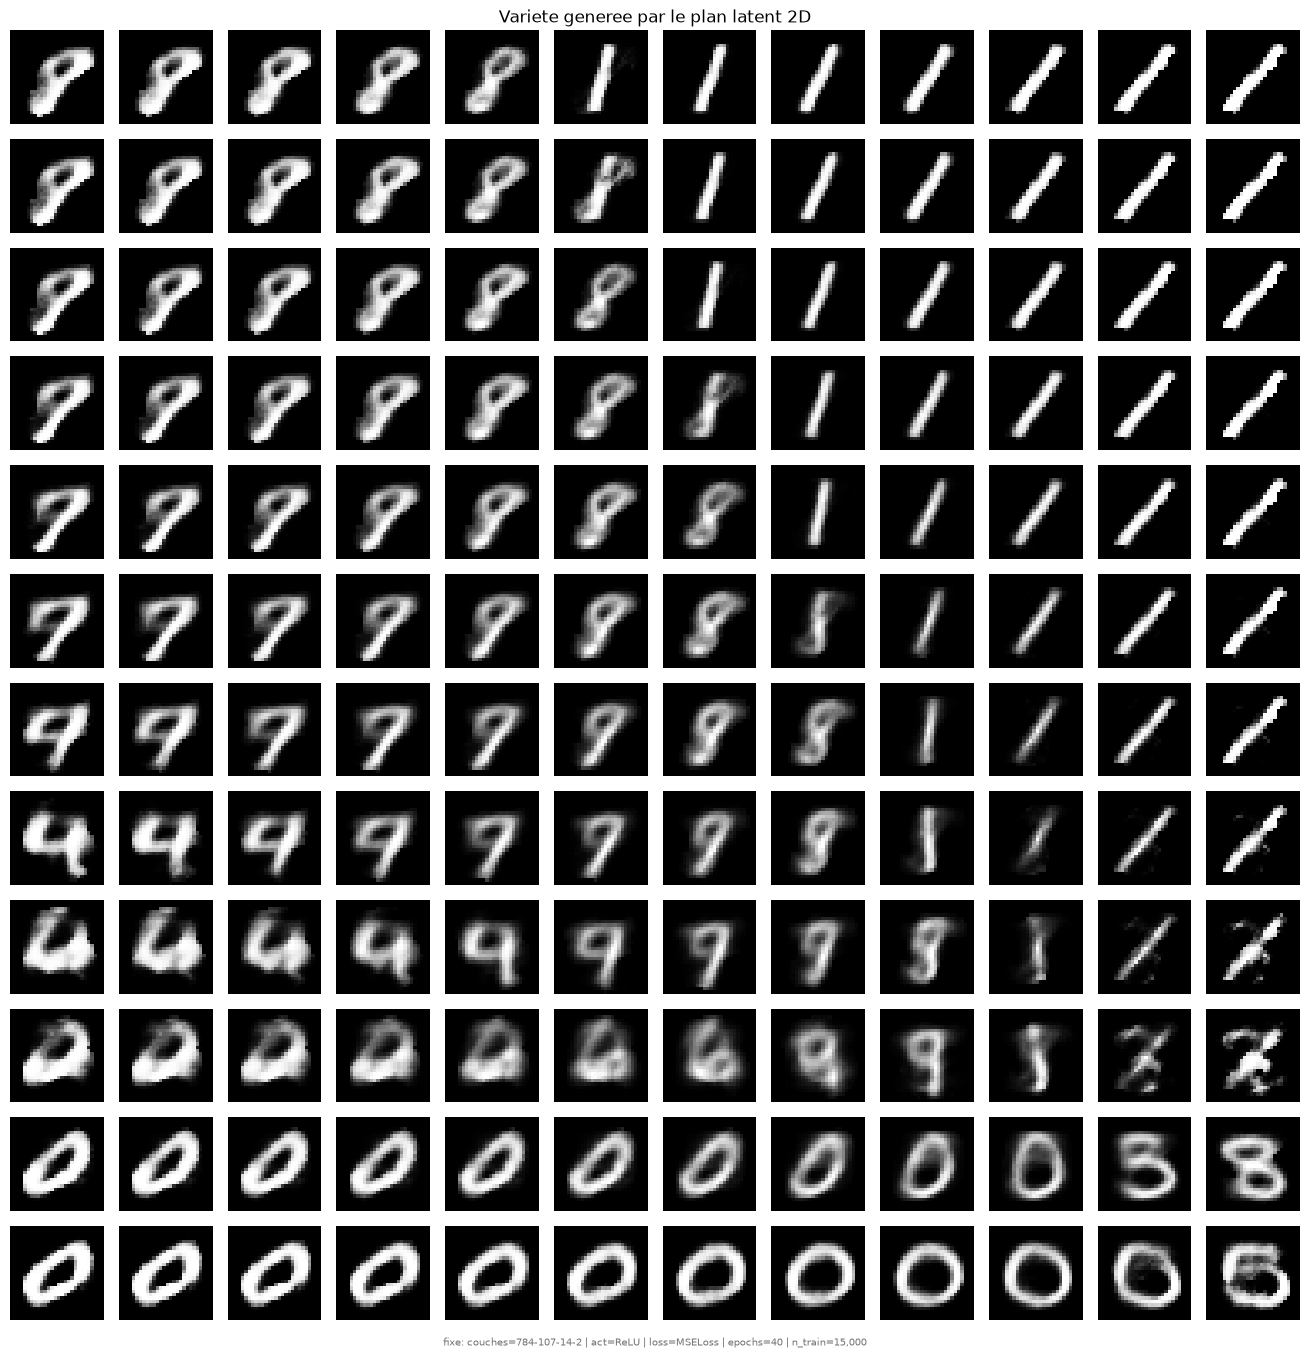

In [8]:
# Echantillonnage gaussien
new_codes = sample_gaussian_latent(mnist_latent.array, n_samples=32)
generated = mnist_model.decode(Latent(array=new_codes, nature="continuous"))
show_image_grid(generated, MNIST_SHAPE, nrow=4, ncol=8,
                title="Chiffres generes (echantillonnage gaussien)",
                config=MNIST_BASELINE_CONFIG)

# Interpolation entre deux images
path = interpolate_latent(mnist_latent.array[0], mnist_latent.array[1], steps=10)
morph = mnist_model.decode(Latent(array=path, nature="continuous"))
show_image_grid(morph, MNIST_SHAPE, nrow=1, ncol=10,
                title="Interpolation dans l'espace latent",
                config=MNIST_BASELINE_CONFIG)

# Balayage du latent
lo, hi = mnist_latent.array.min(axis=0), mnist_latent.array.max(axis=0)
grid_axis = 12
xs = np.linspace(lo[0], hi[0], grid_axis)
ys = np.linspace(hi[1], lo[1], grid_axis)
grid = np.array([[x, y] for y in ys for x in xs], dtype=np.float32)
manifold = mnist_model.decode(Latent(array=grid, nature="continuous"))
show_image_grid(manifold, MNIST_SHAPE, nrow=grid_axis, ncol=grid_axis,
                title="Variete generee par le plan latent 2D",
                config=MNIST_BASELINE_CONFIG)

### Experimentation sur les hyper-parametres - courbes

 ReLU | latent= 2 | MSE=0.0498 | total=  369,276 o | ratio=25.48
 ReLU | latent= 8 | MSE=0.0250 | total=  658,712 o | ratio=14.28
 ReLU | latent=16 | MSE=0.0189 | total=  920,688 o | ratio=10.22
 ReLU | latent=32 | MSE=0.0150 | total=1,342,932 o | ratio=7.01
 ReLU | latent=64 | MSE=0.0122 | total=2,076,876 o | ratio=4.53
 Tanh | latent= 2 | MSE=0.0496 | total=  369,276 o | ratio=25.48
 Tanh | latent= 8 | MSE=0.0295 | total=  658,712 o | ratio=14.28
 Tanh | latent=16 | MSE=0.0264 | total=  920,688 o | ratio=10.22
 Tanh | latent=32 | MSE=0.0223 | total=1,342,932 o | ratio=7.01
 Tanh | latent=64 | MSE=0.0198 | total=2,076,876 o | ratio=4.53


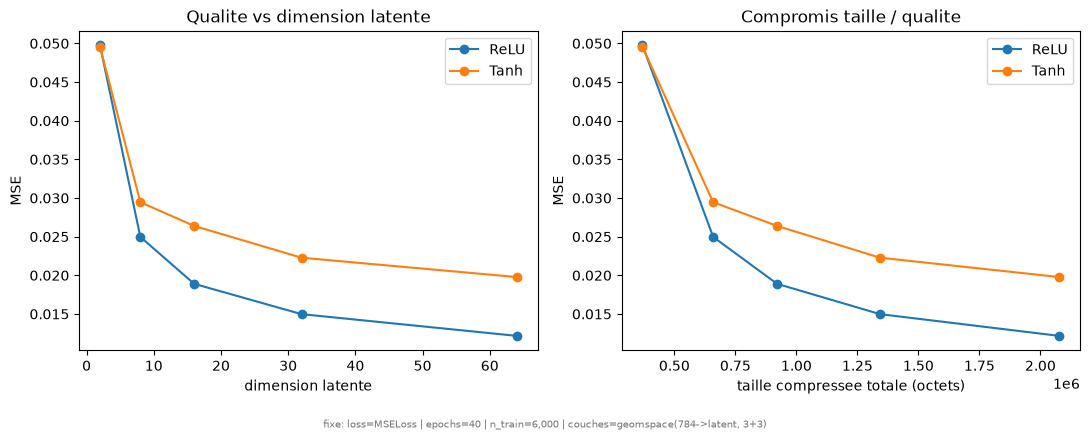

In [9]:
latent_dims = [2, 8, 16, 32, 64]
activations = {"ReLU": nn.ReLU, "Tanh": nn.Tanh}
X_tr, y_tr = subsample_dataset(X_mnist_train, y_mnist_train, 6000, seed=1)

mnist_runs = {}
mnist_results = []
for act_name, act in activations.items():
    for latent_dim in latent_dims:
        run = run_autoencoder_hyperparam_experiment(X_tr, X_mnist_eval, 784, latent_dim, act, EPOCHS_SWEEP)
        mnist_runs[(act_name, latent_dim)] = run
        report = run["report"]
        report.update(latent_dim=latent_dim, activation=act_name)
        mnist_results.append(report)
        print(f"{act_name:>5} | latent={latent_dim:>2} | MSE={report['reconstruction_mse']:.4f} "
              f"| total={report['total_compressed_bytes']:>9,} o | ratio={report['compression_ratio']:.2f}")

# Explore ici: la dimension latente (axe x) et l'activation (legende) -> retirees de la note.
# Les couches suivent la dimension latente, on donne donc la regle plutot qu'une taille.
MNIST_SWEEP_CONFIG = describe_autoencoder(
    mnist_runs[("ReLU", latent_dims[0])]["model"], n_train=len(X_tr),
    omit=("couches", "act"), extra="couches=geomspace(784->latent, 3+3)",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for act_name in activations:
    pts = [r for r in mnist_results if r["activation"] == act_name]
    axes[0].plot([r["latent_dim"] for r in pts], [r["reconstruction_mse"] for r in pts], marker="o", label=act_name)
    axes[1].plot([r["total_compressed_bytes"] for r in pts], [r["reconstruction_mse"] for r in pts], marker="o", label=act_name)
axes[0].set_xlabel("dimension latente"); axes[0].set_ylabel("MSE"); axes[0].set_title("Qualite vs dimension latente"); axes[0].legend()
axes[1].set_xlabel("taille compressee totale (octets)"); axes[1].set_ylabel("MSE"); axes[1].set_title("Compromis taille / qualite"); axes[1].legend()
_finish_figure(fig, config=MNIST_SWEEP_CONFIG)

### Experimentation sur les hyper-parametres - images

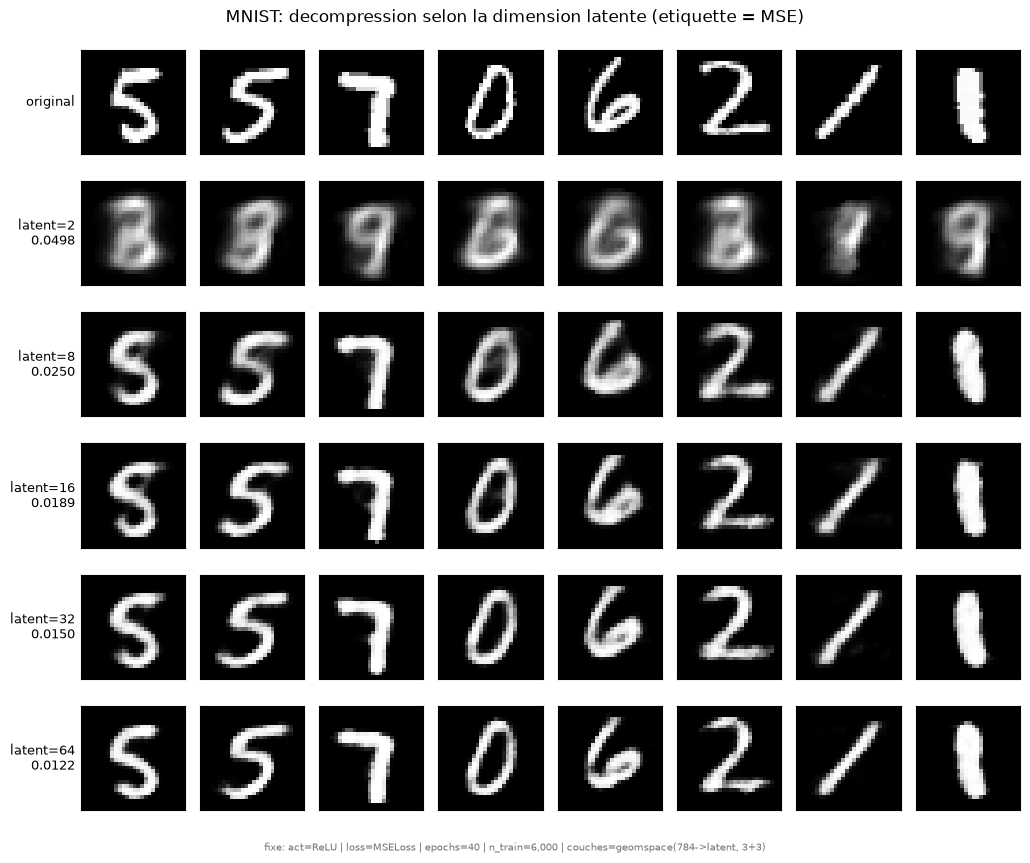

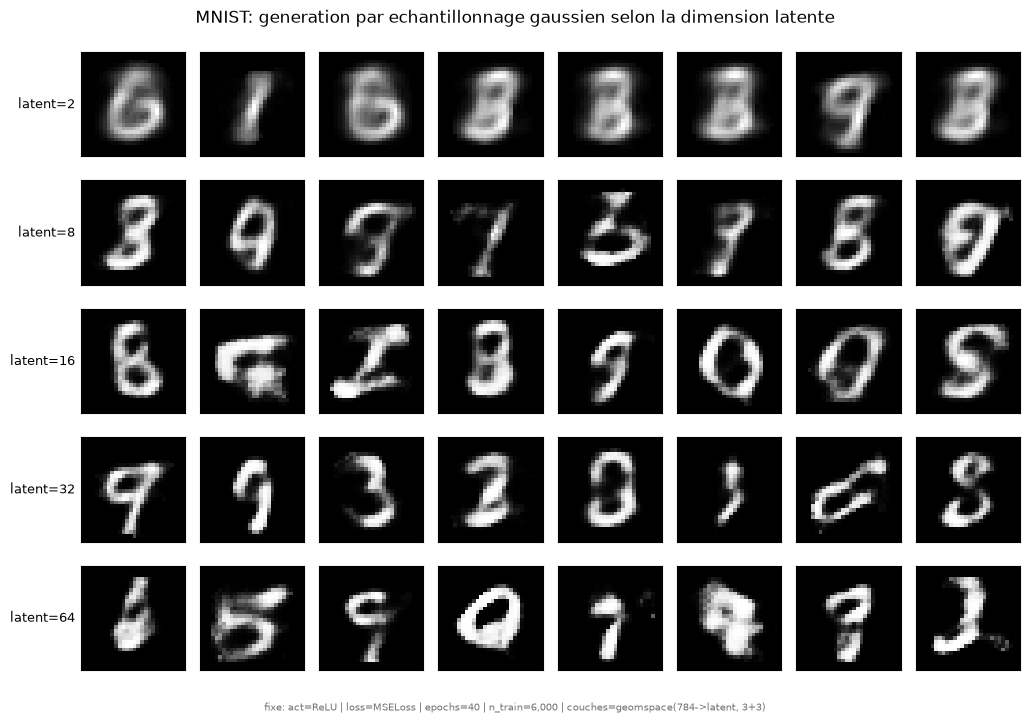

In [10]:
VIZ_ACTIVATION = "ReLU"

# Explore ici: la dimension latente (etiquettes de lignes). Tout le reste est fixe et va dans la note.
latent_sweep_config = describe_autoencoder(
    mnist_runs[(VIZ_ACTIVATION, latent_dims[0])]["model"], n_train=len(X_tr),
    omit=("couches",), extra="couches=geomspace(784->latent, 3+3)",
)

show_labeled_image_rows(
    [X_mnist_eval] + [mnist_runs[(VIZ_ACTIVATION, d)]["reconstruction"] for d in latent_dims],
    MNIST_SHAPE,
    ["original"] + [f"latent={d}\n{mnist_runs[(VIZ_ACTIVATION, d)]['report']['reconstruction_mse']:.4f}" for d in latent_dims],
    n=8, title="MNIST: decompression selon la dimension latente (etiquette = MSE)",
    config=latent_sweep_config,
)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(mnist_runs[(VIZ_ACTIVATION, d)]["model"], mnist_runs[(VIZ_ACTIVATION, d)]["latent"], 8, seed=1)
     for d in latent_dims],
    MNIST_SHAPE,
    [f"latent={d}" for d in latent_dims],
    n=8, title="MNIST: generation par echantillonnage gaussien selon la dimension latente",
    config=latent_sweep_config,
)

#### Espace latent selon la fonction d'activation


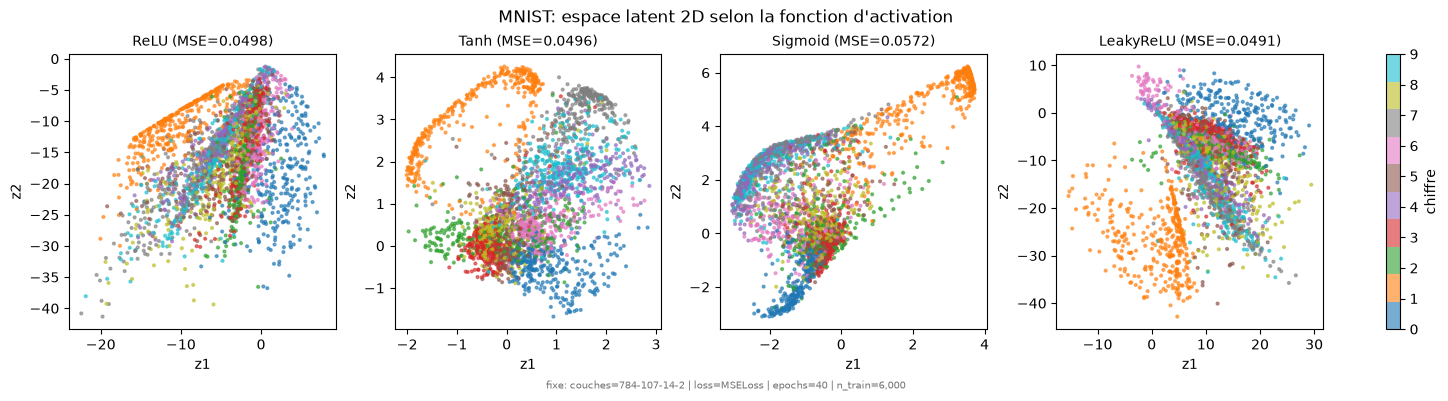

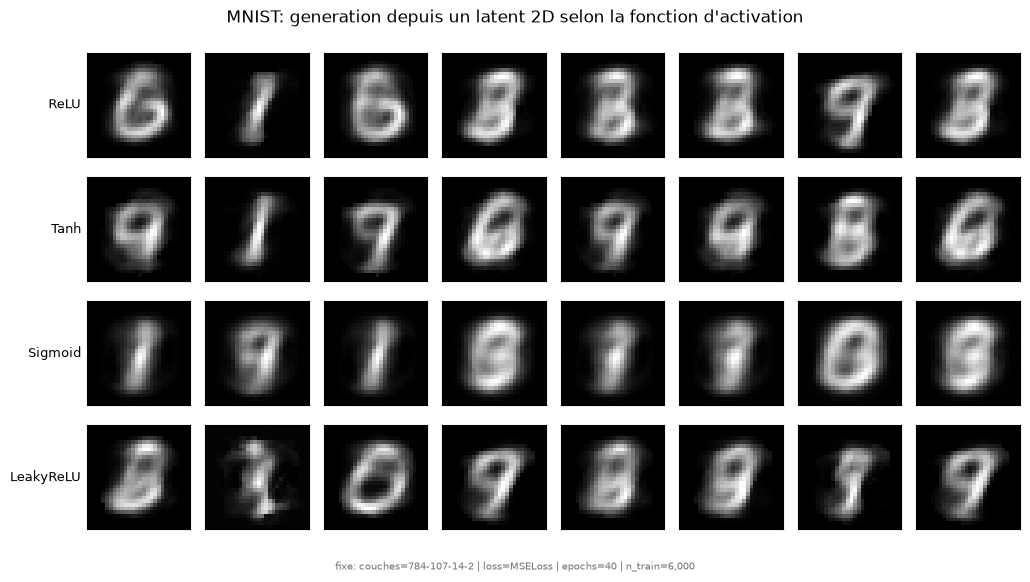

In [11]:
latent_viz_activations = {"ReLU": nn.ReLU, "Tanh": nn.Tanh, "Sigmoid": nn.Sigmoid, "LeakyReLU": nn.LeakyReLU}

for act_name, act in latent_viz_activations.items():
    if (act_name, 2) not in mnist_runs:
        mnist_runs[(act_name, 2)] = run_autoencoder_hyperparam_experiment(
            X_tr, X_mnist_eval, 784, 2, act, EPOCHS_SWEEP
        )

# Explore ici: l'activation (titre de chaque panneau) -> retiree de la note.
activation_viz_config = describe_autoencoder(
    mnist_runs[("ReLU", 2)]["model"], n_train=len(X_tr), omit=("act",)
)

fig, axes = plt.subplots(1, len(latent_viz_activations),
                         figsize=(3.6 * len(latent_viz_activations), 3.9), layout="constrained")
for ax, act_name in zip(axes, latent_viz_activations):
    run = mnist_runs[(act_name, 2)]
    codes = run["latent"].array
    scatter = ax.scatter(codes[:, 0], codes[:, 1], c=y_mnist_eval, cmap="tab10", s=4, alpha=0.6)
    ax.set_title(f"{act_name} (MSE={run['report']['reconstruction_mse']:.4f})", fontsize=10)
    ax.set_xlabel("z1"); ax.set_ylabel("z2")
fig.colorbar(scatter, ax=list(axes), label="chiffre")
_finish_figure(fig, "MNIST: espace latent 2D selon la fonction d'activation",
               activation_viz_config, layout=False)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(mnist_runs[(act_name, 2)]["model"], mnist_runs[(act_name, 2)]["latent"], 8, seed=1)
     for act_name in latent_viz_activations],
    MNIST_SHAPE,
    list(latent_viz_activations),
    n=8, title="MNIST: generation depuis un latent 2D selon la fonction d'activation",
    config=activation_viz_config,
)

### Variation de la fonction de perte
MSE, L1 et BCE

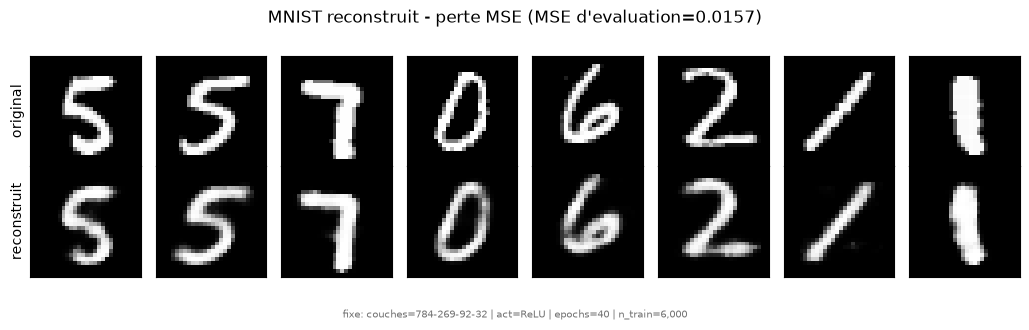

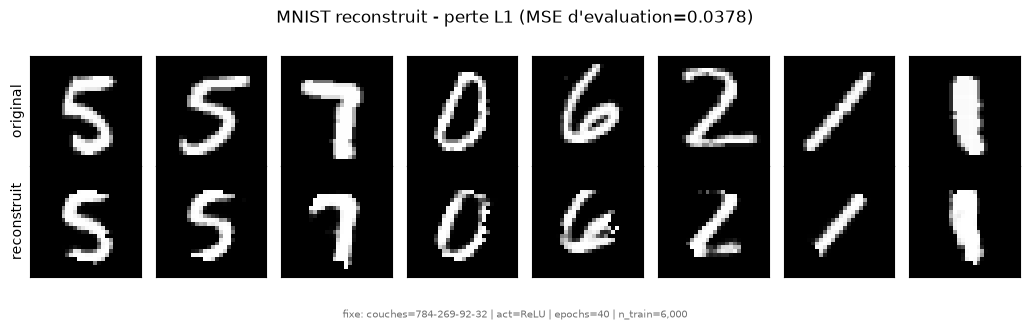

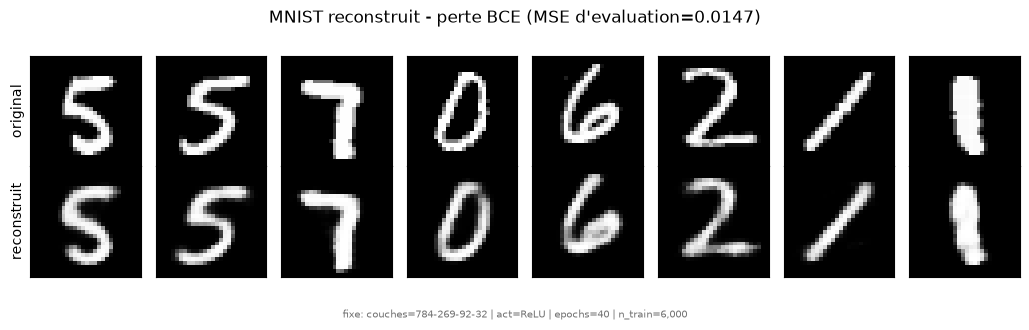

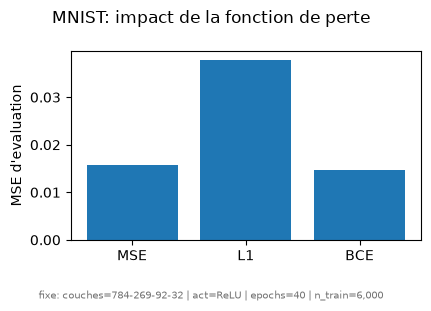

In [12]:
loss_functions = {"MSE": nn.MSELoss, "L1": nn.L1Loss, "BCE": nn.BCELoss}

mnist_loss_mse = {}
loss_config = None
for name, loss_cls in loss_functions.items():
    model = AutoEncoder(input_dim=784, output_dim=784, latent_dim=32,
                        encoder_layer_num=3, decoder_layer_num=3,
                        encoder_activation=nn.ReLU, fonction_loss=loss_cls)
    model.fit(X_tr, epochs=EPOCHS_SWEEP, batch_size=BATCH_SIZE)
    latent = model.encode(X_mnist_eval)
    reconstruction = model.decode(latent)
    mnist_loss_mse[name] = compression_report(model.get_codebook(), latent, X_mnist_eval, reconstruction)["reconstruction_mse"]
    # Explore ici: la perte (titre) -> retiree de la note.
    loss_config = describe_autoencoder(model, n_train=len(X_tr), omit=("loss",))
    show_original_vs_reconstruction_grid(X_mnist_eval, reconstruction, MNIST_SHAPE, n=8,
                         title=f"MNIST reconstruit - perte {name} (MSE d'evaluation={mnist_loss_mse[name]:.4f})",
                         config=loss_config)

fig = plt.figure(figsize=(4.5, 3))
plt.bar(list(mnist_loss_mse), list(mnist_loss_mse.values()))
plt.ylabel("MSE d'evaluation")
_finish_figure(fig, "MNIST: impact de la fonction de perte", loss_config)

## Partie B - shapes

train: (12000, 3072) | eval: (3000, 3072) | classes: ['circle', 'square', 'triangle', 'cross', 'star', 'bar']


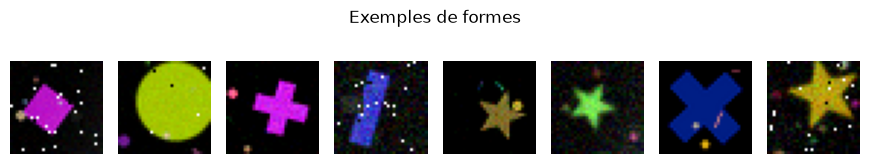

In [13]:
X_shapes_train, y_shapes_train, shape_names = load_shapes_npz(split="train", max_samples=12000)
X_shapes_eval, y_shapes_eval, _ = load_shapes_npz(split="validation", max_samples=3000)
X_shapes_train = X_shapes_train.reshape(len(X_shapes_train), -1)
X_shapes_eval = X_shapes_eval.reshape(len(X_shapes_eval), -1)

SHAPES_SHAPE = (3, 32, 32)
SHAPES_DIM = 3 * 32 * 32
print("train:", X_shapes_train.shape, "| eval:", X_shapes_eval.shape, "| classes:", shape_names)
show_image_grid(X_shapes_eval[:8], SHAPES_SHAPE, nrow=1, ncol=8, title="Exemples de formes")

### Train, compression et decompression

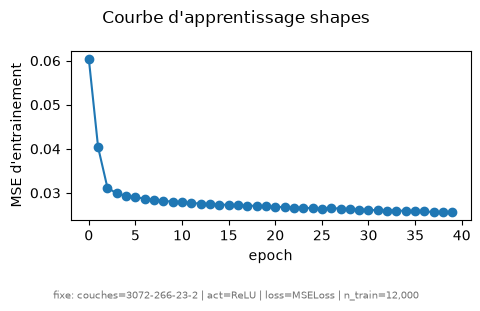

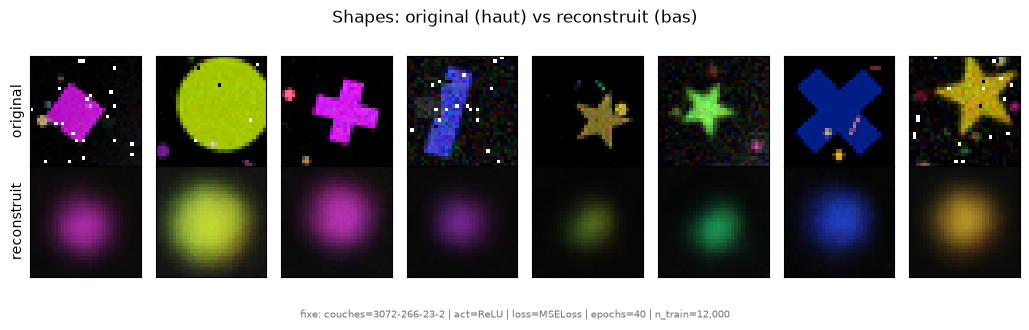

In [14]:
shapes_model = AutoEncoder(input_dim=SHAPES_DIM, output_dim=SHAPES_DIM, latent_dim=2,
                           encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU)
shapes_model.fit(X_shapes_train, epochs=EPOCHS, batch_size=BATCH_SIZE)

SHAPES_BASELINE_CONFIG = describe_autoencoder(shapes_model, n_train=len(X_shapes_train))

fig = plt.figure(figsize=(5, 3))
plt.plot(shapes_model.loss_history, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE d'entrainement")
_finish_figure(fig, "Courbe d'apprentissage shapes",
               describe_autoencoder(shapes_model, n_train=len(X_shapes_train), omit=("epochs",)))

shapes_latent = shapes_model.encode(X_shapes_eval)
shapes_reconstructed = shapes_model.decode(shapes_latent)
show_original_vs_reconstruction_grid(X_shapes_eval, shapes_reconstructed, SHAPES_SHAPE, n=8,
                     title="Shapes: original (haut) vs reconstruit (bas)",
                     config=SHAPES_BASELINE_CONFIG)

### Metriques de compression

In [15]:
shapes_report = compression_report(shapes_model.get_codebook(), shapes_latent, X_shapes_eval, shapes_reconstructed)
print_compression_report(shapes_report)

per_image_bytes = shapes_latent.n_bytes / len(X_shapes_eval)
print(f"\nMessage par image: {per_image_bytes:.0f} octets contre {X_shapes_eval[0].nbytes} octets en float32.")

           latent_nature: continuous
          codebook_bytes: 3306708
            latent_bytes: 24000
  total_compressed_bytes: 3330708
          original_bytes: 36864000
       compression_ratio: 11.0679
      reconstruction_mse: 0.0270

Message par image: 8 octets contre 12288 octets en float32.


### Espace latent et generation

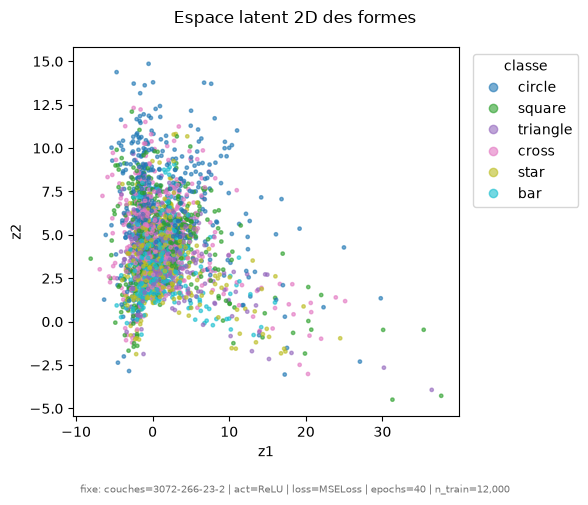

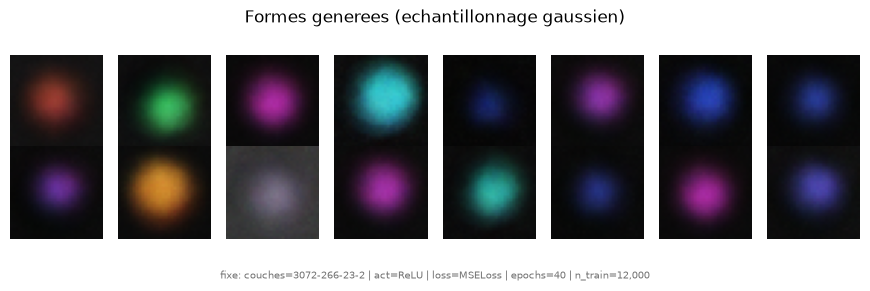

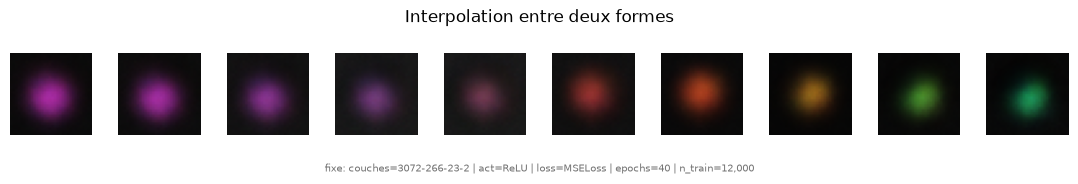

In [16]:
plot_latent_scatter(shapes_latent.array, y_shapes_eval, class_names=shape_names,
                    title="Espace latent 2D des formes",
                    config=SHAPES_BASELINE_CONFIG)

# Generation par echantillonnage gaussien
new_codes = sample_gaussian_latent(shapes_latent.array, n_samples=16)
generated = shapes_model.decode(Latent(array=new_codes, nature="continuous"))
show_image_grid(generated, SHAPES_SHAPE, nrow=2, ncol=8,
                title="Formes generees (echantillonnage gaussien)",
                config=SHAPES_BASELINE_CONFIG)

# Interpolation entre deux formes
path = interpolate_latent(shapes_latent.array[0], shapes_latent.array[5], steps=10)
morph = shapes_model.decode(Latent(array=path, nature="continuous"))
show_image_grid(morph, SHAPES_SHAPE, nrow=1, ncol=10,
                title="Interpolation entre deux formes",
                config=SHAPES_BASELINE_CONFIG)

### Experimentation hyper-parametres

latent= 2 | MSE=0.0284 | total=3,330,708 o | ratio=11.07
latent= 8 | MSE=0.0167 | total=5,395,504 o | ratio=6.83
latent=16 | MSE=0.0139 | total=6,945,664 o | ratio=5.31
latent=32 | MSE=0.0132 | total=9,042,480 o | ratio=4.08
latent=64 | MSE=0.0127 | total=12,011,508 o | ratio=3.07


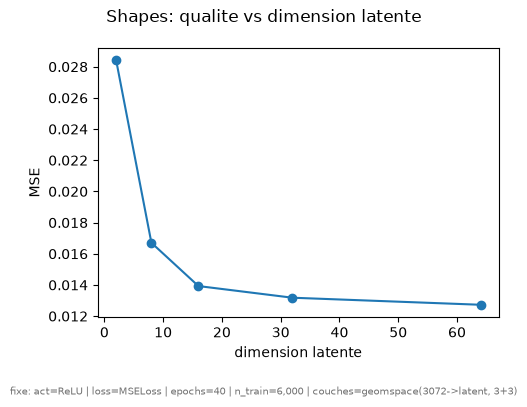

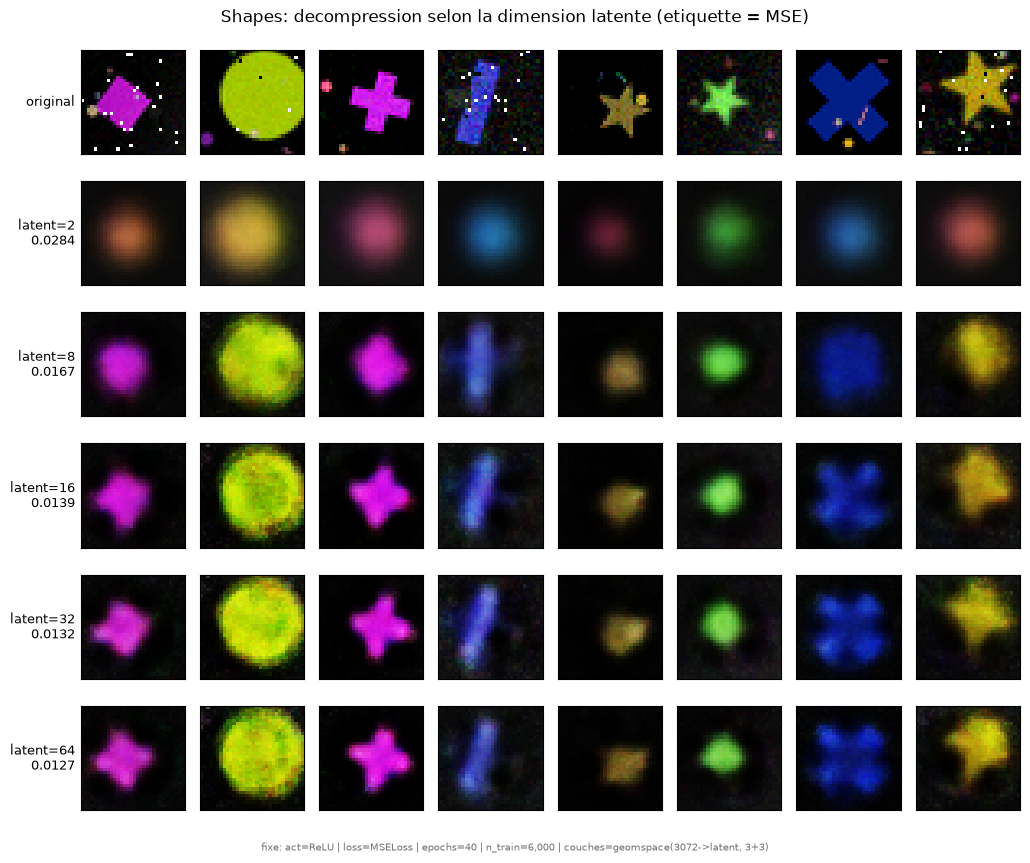

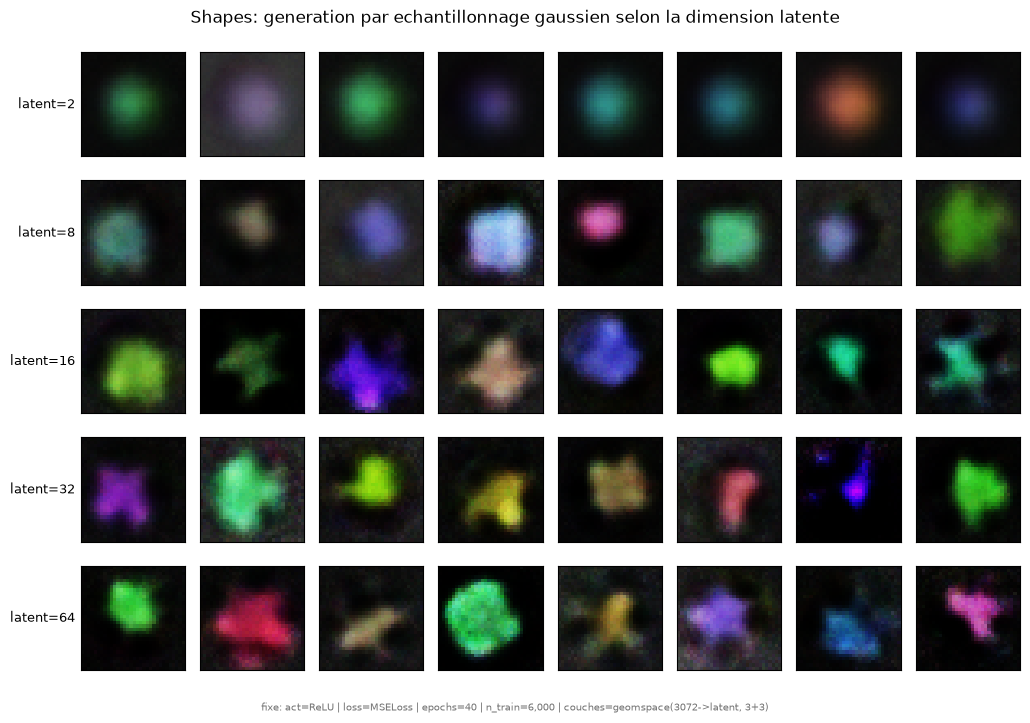

In [17]:
X_shapes_tr, _ = subsample_dataset(X_shapes_train, y_shapes_train, 6000, seed=1)
shapes_runs = {}
shapes_results = []
for latent_dim in latent_dims:
    run = run_autoencoder_hyperparam_experiment(X_shapes_tr, X_shapes_eval, SHAPES_DIM, latent_dim, nn.ReLU, EPOCHS_SWEEP)
    shapes_runs[latent_dim] = run
    report = run["report"]
    report.update(latent_dim=latent_dim)
    shapes_results.append(report)
    print(f"latent={latent_dim:>2} | MSE={report['reconstruction_mse']:.4f} "
          f"| total={report['total_compressed_bytes']:>9,} o | ratio={report['compression_ratio']:.2f}")

# Explore ici: la dimension latente (axe x, puis etiquettes de lignes).
shapes_sweep_config = describe_autoencoder(
    shapes_runs[latent_dims[0]]["model"], n_train=len(X_shapes_tr),
    omit=("couches",), extra=f"couches=geomspace({SHAPES_DIM}->latent, 3+3)",
)

fig = plt.figure(figsize=(5, 4))
plt.plot([r["latent_dim"] for r in shapes_results], [r["reconstruction_mse"] for r in shapes_results], marker="o")
plt.xlabel("dimension latente"); plt.ylabel("MSE")
_finish_figure(fig, "Shapes: qualite vs dimension latente", shapes_sweep_config)

# Decompression et generation selon la dimension latente
show_labeled_image_rows(
    [X_shapes_eval] + [shapes_runs[d]["reconstruction"] for d in latent_dims],
    SHAPES_SHAPE,
    ["original"] + [f"latent={d}\n{shapes_runs[d]['report']['reconstruction_mse']:.4f}" for d in latent_dims],
    n=8, title="Shapes: decompression selon la dimension latente (etiquette = MSE)",
    config=shapes_sweep_config,
)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(shapes_runs[d]["model"], shapes_runs[d]["latent"], 8, seed=1) for d in latent_dims],
    SHAPES_SHAPE,
    [f"latent={d}" for d in latent_dims],
    n=8, title="Shapes: generation par echantillonnage gaussien selon la dimension latente",
    config=shapes_sweep_config,
)

### Variation de la fonction de perte
MSE, L1, BCE

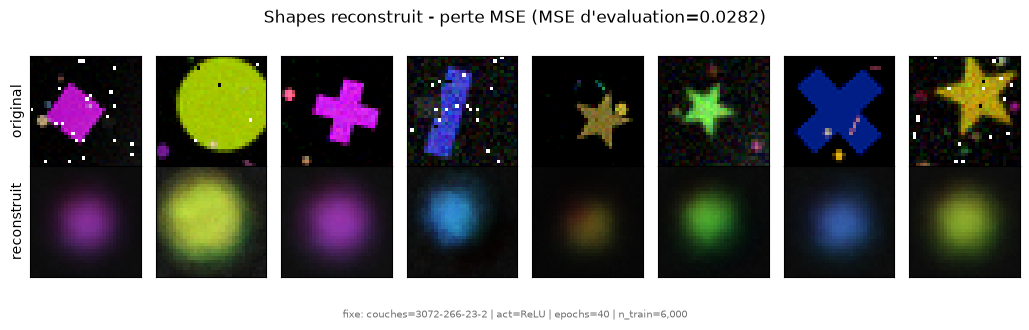

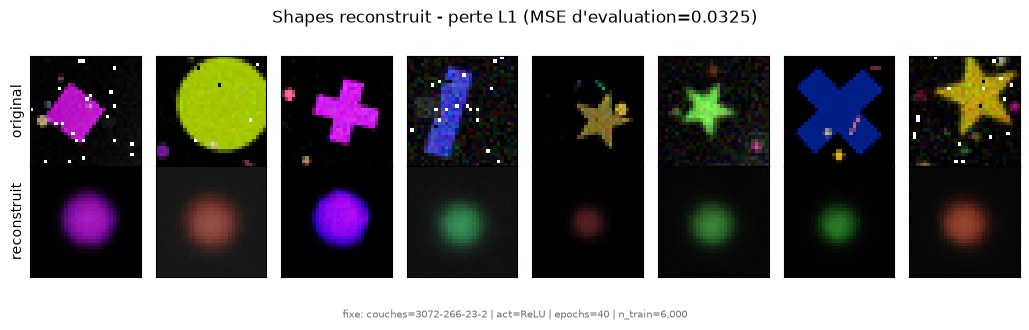

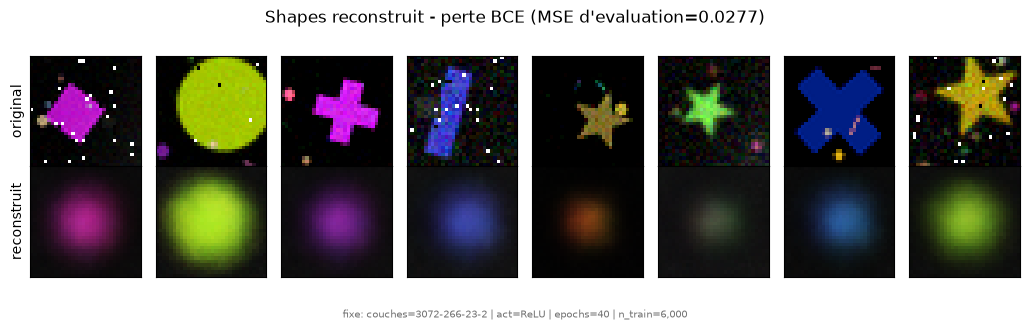

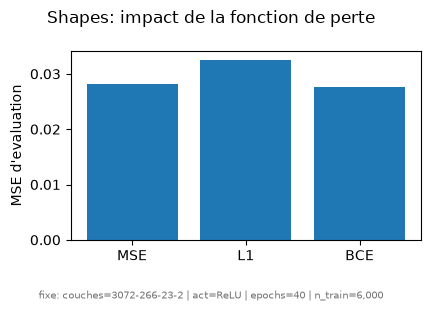

In [18]:
shapes_loss_mse = {}
shapes_loss_config = None
for name, loss_cls in loss_functions.items():
    model = AutoEncoder(input_dim=SHAPES_DIM, output_dim=SHAPES_DIM, latent_dim=2,
                        encoder_layer_num=3, decoder_layer_num=3,
                        encoder_activation=nn.ReLU, fonction_loss=loss_cls)
    model.fit(X_shapes_tr, epochs=EPOCHS_SWEEP, batch_size=BATCH_SIZE)
    latent = model.encode(X_shapes_eval)
    reconstruction = model.decode(latent)
    shapes_loss_mse[name] = compression_report(model.get_codebook(), latent, X_shapes_eval, reconstruction)["reconstruction_mse"]
    shapes_loss_config = describe_autoencoder(model, n_train=len(X_shapes_tr), omit=("loss",))
    show_original_vs_reconstruction_grid(X_shapes_eval, reconstruction, SHAPES_SHAPE, n=8,
                         title=f"Shapes reconstruit - perte {name} (MSE d'evaluation={shapes_loss_mse[name]:.4f})",
                         config=shapes_loss_config)

fig = plt.figure(figsize=(4.5, 3))
plt.bar(list(shapes_loss_mse), list(shapes_loss_mse.values()))
plt.ylabel("MSE d'evaluation")
_finish_figure(fig, "Shapes: impact de la fonction de perte", shapes_loss_config)

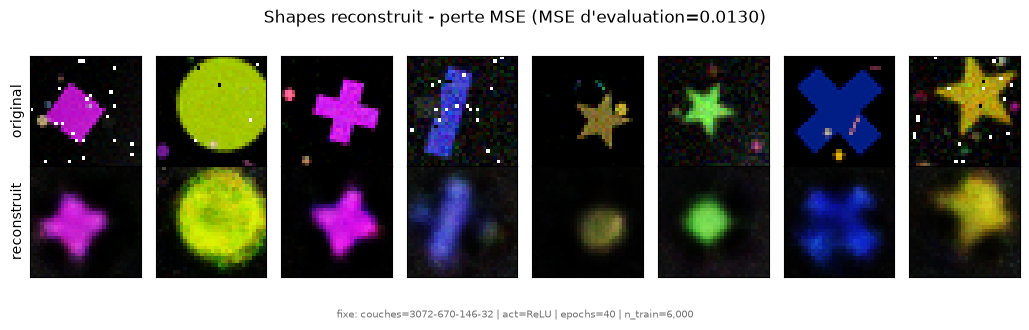

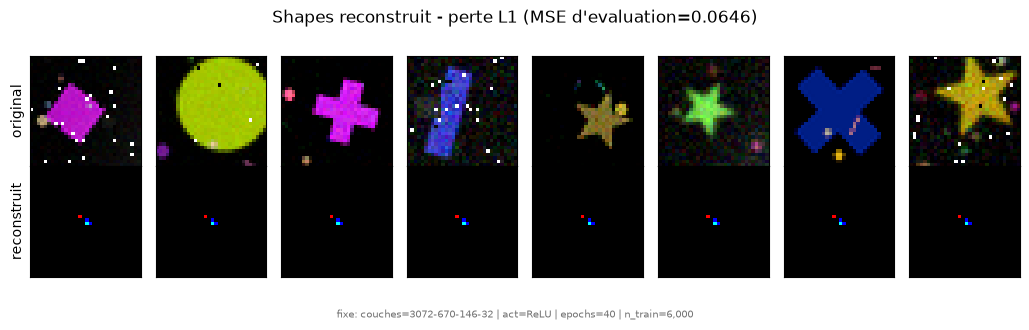

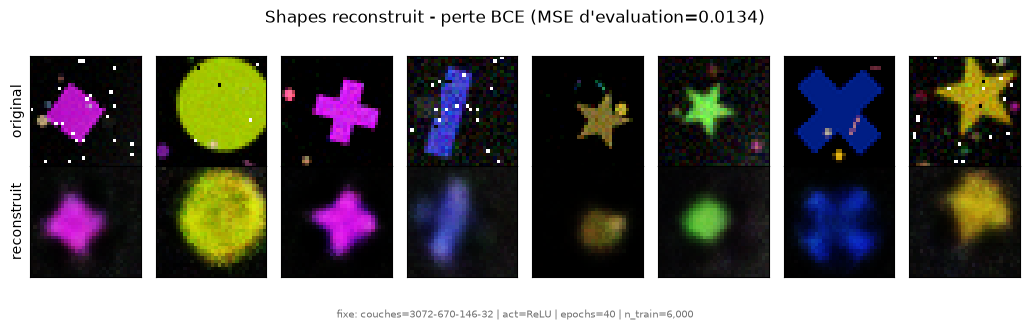

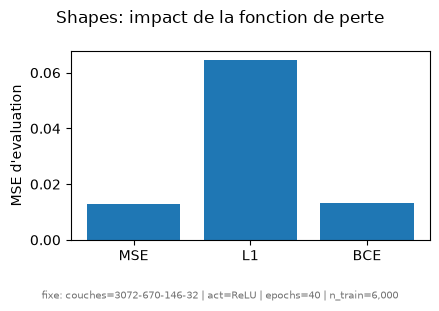

In [21]:
shapes_loss_mse = {}
shapes_loss_config = None
for name, loss_cls in loss_functions.items():
    model = AutoEncoder(input_dim=SHAPES_DIM, output_dim=SHAPES_DIM, latent_dim=32,
                        encoder_layer_num=3, decoder_layer_num=3,
                        encoder_activation=nn.ReLU, fonction_loss=loss_cls)
    model.fit(X_shapes_tr, epochs=EPOCHS_SWEEP, batch_size=BATCH_SIZE)
    latent = model.encode(X_shapes_eval)
    reconstruction = model.decode(latent)
    shapes_loss_mse[name] = compression_report(model.get_codebook(), latent, X_shapes_eval, reconstruction)["reconstruction_mse"]
    shapes_loss_config = describe_autoencoder(model, n_train=len(X_shapes_tr), omit=("loss",))
    show_original_vs_reconstruction_grid(X_shapes_eval, reconstruction, SHAPES_SHAPE, n=8,
                         title=f"Shapes reconstruit - perte {name} (MSE d'evaluation={shapes_loss_mse[name]:.4f})",
                         config=shapes_loss_config)

fig = plt.figure(figsize=(4.5, 3))
plt.bar(list(shapes_loss_mse), list(shapes_loss_mse.values()))
plt.ylabel("MSE d'evaluation")
_finish_figure(fig, "Shapes: impact de la fonction de perte", shapes_loss_config)

## Experimentation - nombre d'epochs

Chaque budget entraine un modele independant plutot que de prolonger le precedent: `fit`
reinstancie son optimiseur Adam a chaque appel, donc 4 appels de 20 epochs ne seraient pas
equivalents a un seul de 80.

epochs=  5 | MSE train=0.0596 | MSE eval=0.0589 | ecart=-0.0007 | BCE finale=0.2452
epochs= 10 | MSE train=0.0557 | MSE eval=0.0549 | ecart=-0.0008 | BCE finale=0.2280
epochs= 20 | MSE train=0.0523 | MSE eval=0.0520 | ecart=-0.0004 | BCE finale=0.2179
epochs= 40 | MSE train=0.0486 | MSE eval=0.0488 | ecart=+0.0002 | BCE finale=0.2048
epochs= 80 | MSE train=0.0443 | MSE eval=0.0460 | ecart=+0.0017 | BCE finale=0.1930

Meilleur budget sur la MSE d'evaluation: 80 epochs


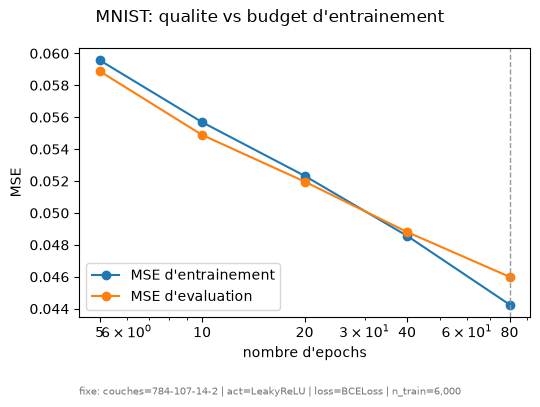

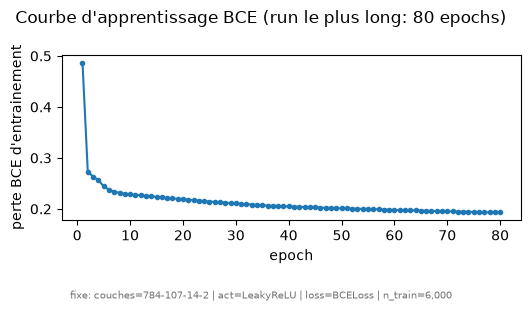

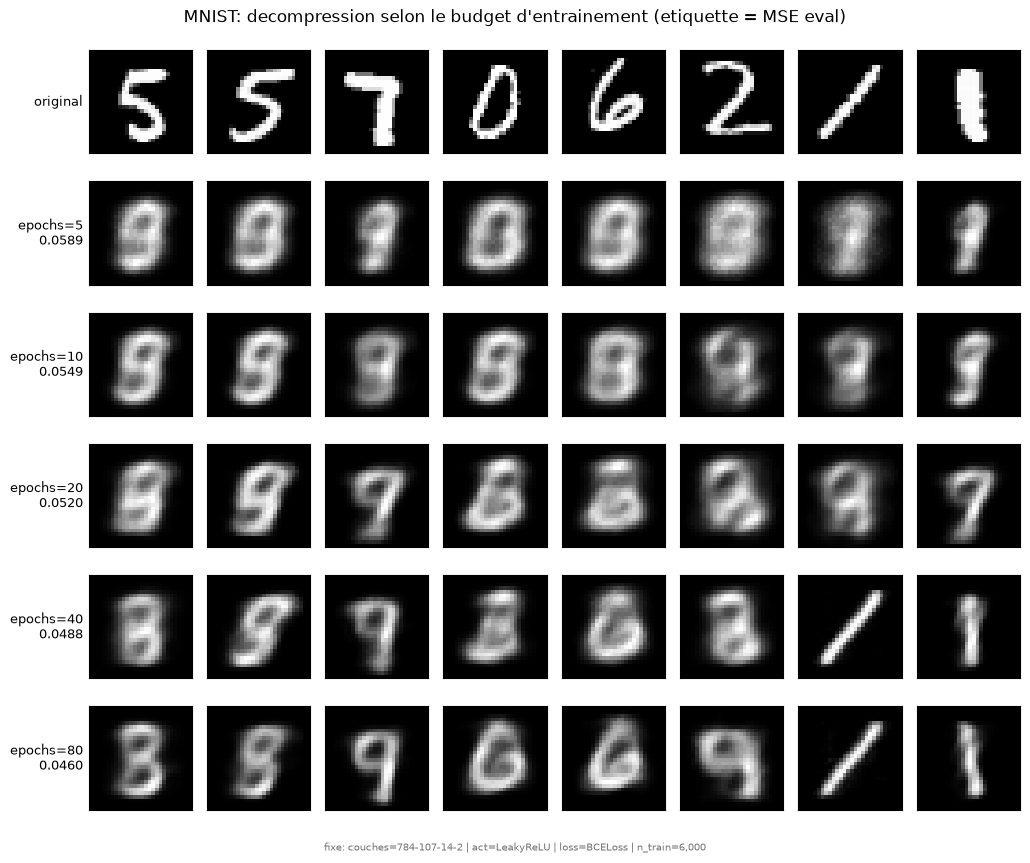

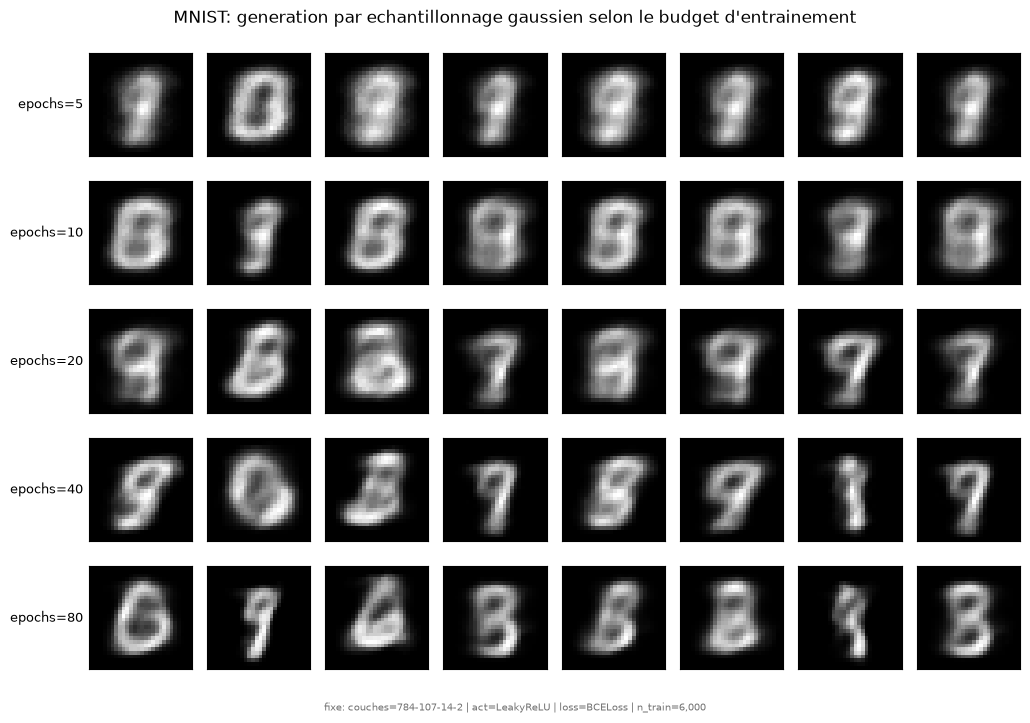

In [19]:
EPOCH_BUDGETS = [5, 10, 20, 40, 80]
EPOCH_EXP_LATENT = 2

epoch_runs = {}
for budget in EPOCH_BUDGETS:
    run = run_autoencoder_hyperparam_experiment(
        X_tr, X_mnist_eval, 784, EPOCH_EXP_LATENT, nn.LeakyReLU, budget, loss_function=nn.BCELoss
    )
    # MSE d'entrainement: comparable a la MSE d'evaluation, contrairement a la perte BCE.
    train_reconstruction = run["model"].decode(run["model"].encode(X_tr))
    run["train_mse"] = float(np.mean((X_tr - train_reconstruction) ** 2))
    epoch_runs[budget] = run
    print(f"epochs={budget:>3} | MSE train={run['train_mse']:.4f} | MSE eval={run['report']['reconstruction_mse']:.4f} "
          f"| ecart={run['report']['reconstruction_mse'] - run['train_mse']:+.4f} "
          f"| BCE finale={run['model'].loss_history[-1]:.4f}")

best_budget = min(EPOCH_BUDGETS, key=lambda b: epoch_runs[b]["report"]["reconstruction_mse"])
print(f"\nMeilleur budget sur la MSE d'evaluation: {best_budget} epochs")

# Explore ici: le nombre d'epochs (axe x / etiquettes de lignes) -> retire de la note.
epochs_config = describe_autoencoder(
    epoch_runs[EPOCH_BUDGETS[-1]]["model"], n_train=len(X_tr), omit=("epochs",)
)

# 1. Sous- ou sur-apprentissage: les deux MSE dans la meme unite.
fig = plt.figure(figsize=(5.5, 4))
plt.plot(EPOCH_BUDGETS, [epoch_runs[b]["train_mse"] for b in EPOCH_BUDGETS],
         marker="o", label="MSE d'entrainement")
plt.plot(EPOCH_BUDGETS, [epoch_runs[b]["report"]["reconstruction_mse"] for b in EPOCH_BUDGETS],
         marker="o", label="MSE d'evaluation")
plt.axvline(best_budget, color="0.6", linestyle="--", linewidth=1)
plt.xscale("log"); plt.xticks(EPOCH_BUDGETS, [str(b) for b in EPOCH_BUDGETS])
plt.xlabel("nombre d'epochs"); plt.ylabel("MSE"); plt.legend()
_finish_figure(fig, "MNIST: qualite vs budget d'entrainement", epochs_config)

# 2. Vue optimisation: la perte reellement minimisee, sur le run le plus long.
longest_model = epoch_runs[EPOCH_BUDGETS[-1]]["model"]
fig = plt.figure(figsize=(5.5, 3))
plt.plot(range(1, len(longest_model.loss_history) + 1), longest_model.loss_history, marker=".")
plt.xlabel("epoch"); plt.ylabel("perte BCE d'entrainement")
_finish_figure(fig, f"Courbe d'apprentissage BCE (run le plus long: {EPOCH_BUDGETS[-1]} epochs)",
               describe_autoencoder(longest_model, n_train=len(X_tr), omit=("epochs",)))

# 3. Effet visuel du budget sur la decompression puis la generation.
show_labeled_image_rows(
    [X_mnist_eval] + [epoch_runs[b]["reconstruction"] for b in EPOCH_BUDGETS],
    MNIST_SHAPE,
    ["original"] + [f"epochs={b}\n{epoch_runs[b]['report']['reconstruction_mse']:.4f}" for b in EPOCH_BUDGETS],
    n=8, title="MNIST: decompression selon le budget d'entrainement (etiquette = MSE eval)",
    config=epochs_config,
)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(epoch_runs[b]["model"], epoch_runs[b]["latent"], 8, seed=1)
     for b in EPOCH_BUDGETS],
    MNIST_SHAPE,
    [f"epochs={b}" for b in EPOCH_BUDGETS],
    n=8, title="MNIST: generation par echantillonnage gaussien selon le budget d'entrainement",
    config=epochs_config,
)

epochs=  5 | MSE train=0.0577 | MSE eval=0.0569 | ecart=-0.0008 | BCE finale=0.2385
epochs= 10 | MSE train=0.0441 | MSE eval=0.0434 | ecart=-0.0008 | BCE finale=0.1943
epochs= 20 | MSE train=0.0377 | MSE eval=0.0375 | ecart=-0.0002 | BCE finale=0.1749
epochs= 40 | MSE train=0.0328 | MSE eval=0.0337 | ecart=+0.0009 | BCE finale=0.1606
epochs= 80 | MSE train=0.0299 | MSE eval=0.0326 | ecart=+0.0027 | BCE finale=0.1519

Meilleur budget sur la MSE d'evaluation: 80 epochs


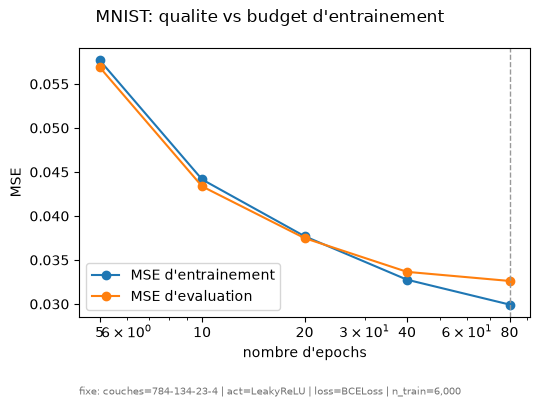

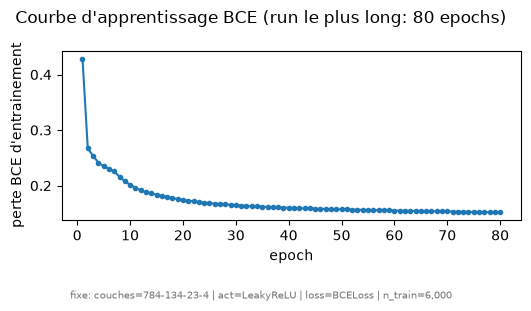

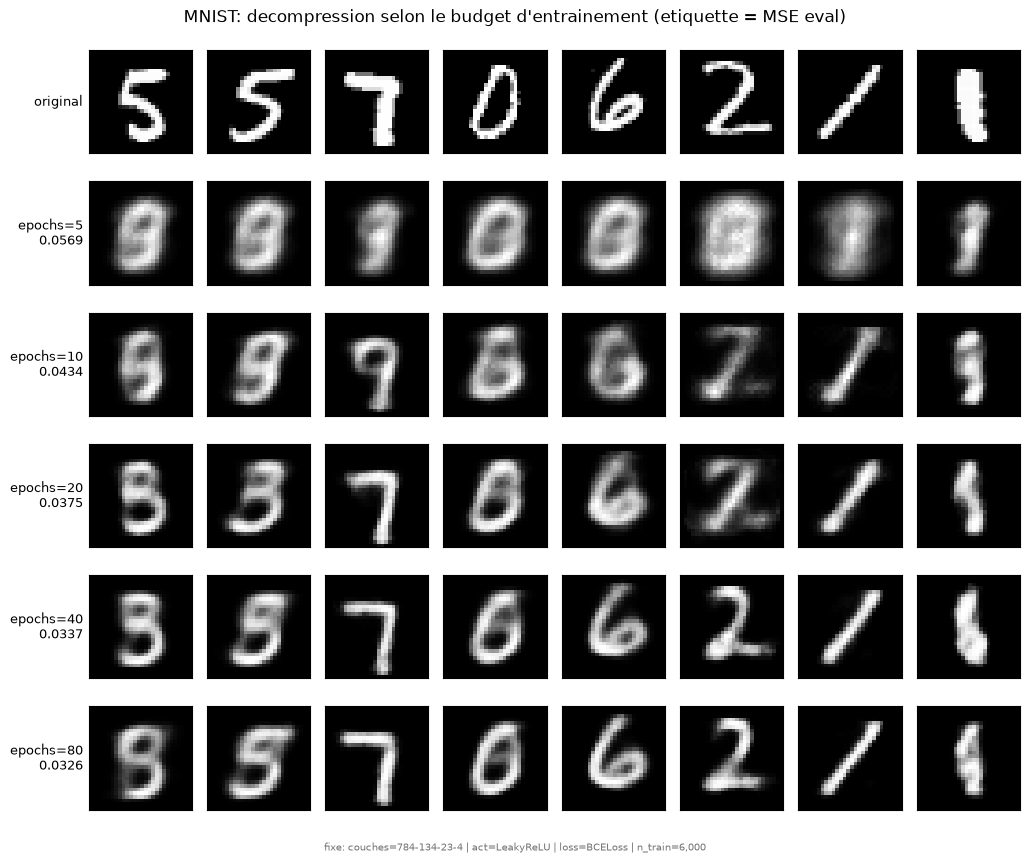

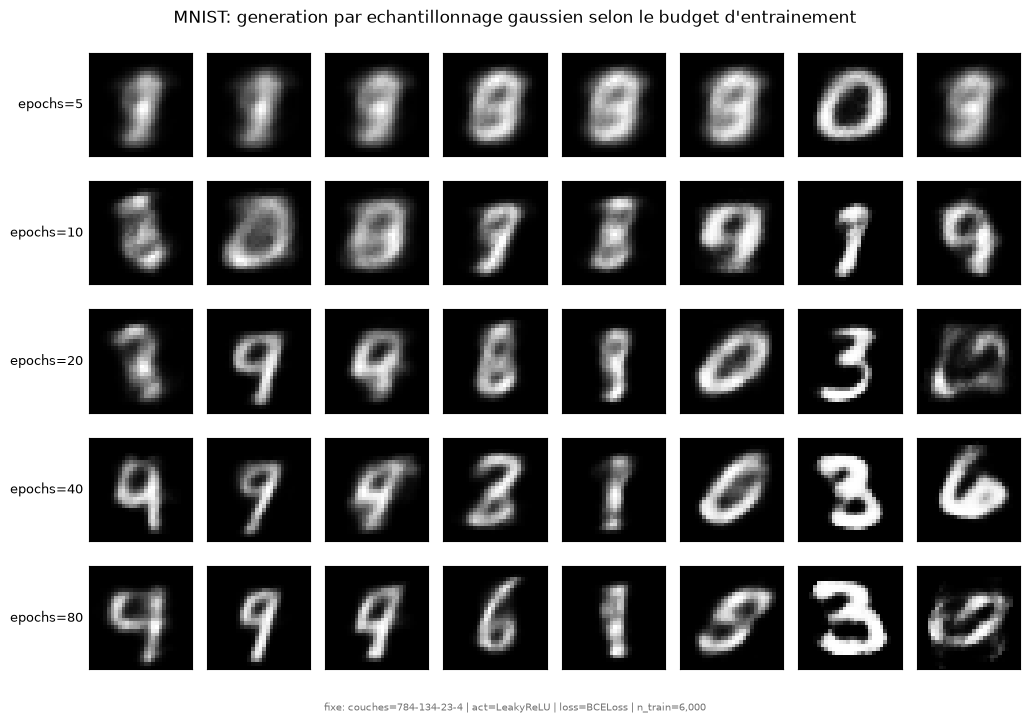

In [20]:
EPOCH_BUDGETS = [5, 10, 20, 40, 80]
EPOCH_EXP_LATENT = 4

epoch_runs = {}
for budget in EPOCH_BUDGETS:
    run = run_autoencoder_hyperparam_experiment(
        X_tr, X_mnist_eval, 784, EPOCH_EXP_LATENT, nn.LeakyReLU, budget, loss_function=nn.BCELoss
    )
    # MSE d'entrainement: comparable a la MSE d'evaluation, contrairement a la perte BCE.
    train_reconstruction = run["model"].decode(run["model"].encode(X_tr))
    run["train_mse"] = float(np.mean((X_tr - train_reconstruction) ** 2))
    epoch_runs[budget] = run
    print(f"epochs={budget:>3} | MSE train={run['train_mse']:.4f} | MSE eval={run['report']['reconstruction_mse']:.4f} "
          f"| ecart={run['report']['reconstruction_mse'] - run['train_mse']:+.4f} "
          f"| BCE finale={run['model'].loss_history[-1]:.4f}")

best_budget = min(EPOCH_BUDGETS, key=lambda b: epoch_runs[b]["report"]["reconstruction_mse"])
print(f"\nMeilleur budget sur la MSE d'evaluation: {best_budget} epochs")

# Explore ici: le nombre d'epochs (axe x / etiquettes de lignes) -> retire de la note.
epochs_config = describe_autoencoder(
    epoch_runs[EPOCH_BUDGETS[-1]]["model"], n_train=len(X_tr), omit=("epochs",)
)

# 1. Sous- ou sur-apprentissage: les deux MSE dans la meme unite.
fig = plt.figure(figsize=(5.5, 4))
plt.plot(EPOCH_BUDGETS, [epoch_runs[b]["train_mse"] for b in EPOCH_BUDGETS],
         marker="o", label="MSE d'entrainement")
plt.plot(EPOCH_BUDGETS, [epoch_runs[b]["report"]["reconstruction_mse"] for b in EPOCH_BUDGETS],
         marker="o", label="MSE d'evaluation")
plt.axvline(best_budget, color="0.6", linestyle="--", linewidth=1)
plt.xscale("log"); plt.xticks(EPOCH_BUDGETS, [str(b) for b in EPOCH_BUDGETS])
plt.xlabel("nombre d'epochs"); plt.ylabel("MSE"); plt.legend()
_finish_figure(fig, "MNIST: qualite vs budget d'entrainement", epochs_config)

# 2. Vue optimisation: la perte reellement minimisee, sur le run le plus long.
longest_model = epoch_runs[EPOCH_BUDGETS[-1]]["model"]
fig = plt.figure(figsize=(5.5, 3))
plt.plot(range(1, len(longest_model.loss_history) + 1), longest_model.loss_history, marker=".")
plt.xlabel("epoch"); plt.ylabel("perte BCE d'entrainement")
_finish_figure(fig, f"Courbe d'apprentissage BCE (run le plus long: {EPOCH_BUDGETS[-1]} epochs)",
               describe_autoencoder(longest_model, n_train=len(X_tr), omit=("epochs",)))

# 3. Effet visuel du budget sur la decompression puis la generation.
show_labeled_image_rows(
    [X_mnist_eval] + [epoch_runs[b]["reconstruction"] for b in EPOCH_BUDGETS],
    MNIST_SHAPE,
    ["original"] + [f"epochs={b}\n{epoch_runs[b]['report']['reconstruction_mse']:.4f}" for b in EPOCH_BUDGETS],
    n=8, title="MNIST: decompression selon le budget d'entrainement (etiquette = MSE eval)",
    config=epochs_config,
)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(epoch_runs[b]["model"], epoch_runs[b]["latent"], 8, seed=1)
     for b in EPOCH_BUDGETS],
    MNIST_SHAPE,
    [f"epochs={b}" for b in EPOCH_BUDGETS],
    n=8, title="MNIST: generation par echantillonnage gaussien selon le budget d'entrainement",
    config=epochs_config,
)

## Experimentation - activation du code latent

Jusqu'ici le code latent est toujours la sortie brute d'un `nn.Linear`: `build_layers` ne pose
d'activation qu'*entre* les couches, jamais sur la derniere. L'espace latent est donc non borne,
et c'est ce qui autorise les codes a s'etaler a n'importe quelle echelle.

`AutoEncoder` accepte maintenant `latent_activation`, appliquee a la sortie de l'encodeur: le
code devient `act(Linear(...))`. On compare ici trois latents a dimension 2 (la seule
directement visualisable), tout le reste etant fixe.

Ce qu'il faut regarder:

- **lineaire** (defaut): nuage non borne, notre reference.
- **ReLU**: le code ne peut plus etre negatif, le nuage est confine au quadrant positif. Les
  unites mortes sortent exactement 0, donc des codes s'ecrasent sur les axes: la moitie du plan
  est inutilisable.
- **Sigmoid**: le code est ecrase dans (0,1) et sature vers les bords. C'est aussi la variante
  qui etrangle le plus le gradient, donc on attend la pire MSE.

Le point le plus interessant est la generation. `sample_gaussian_latent` ajuste une gaussienne
*non bornee* (`np.cov` + `multivariate_normal`). Face a un nuage borne (Sigmoid) ou unilateral
(ReLU), une bonne part des codes tires tombe hors de ce que l'encodeur peut produire: le
decodeur n'y a jamais ete entraine, et les images se degradent. Ce n'est pas un bug a corriger
en tronquant dans `sample_gaussian_latent` - ce serait modifier en silence les figures
precedentes - c'est le resultat de l'experience.

In [ ]:
latent_activations = {"lineaire": None, "ReLU": nn.ReLU, "Sigmoid": nn.Sigmoid}
LATENT_ACT_DIM = 2

latent_act_runs = {}
for act_name, act in latent_activations.items():
    run = run_autoencoder_hyperparam_experiment(
        X_tr, X_mnist_eval, 784, LATENT_ACT_DIM, nn.ReLU, EPOCHS_SWEEP,
        loss_function=nn.MSELoss, latent_activation=act,
    )
    codes = run["latent"].array
    latent_act_runs[act_name] = run
    print(f"{act_name:>8} | MSE={run['report']['reconstruction_mse']:.4f} "
          f"| z1 dans [{codes[:, 0].min():+.2f}, {codes[:, 0].max():+.2f}] "
          f"| z2 dans [{codes[:, 1].min():+.2f}, {codes[:, 1].max():+.2f}] "
          f"| codes exactement nuls: {100 * np.mean(codes == 0):.1f}%")

# Part des codes gaussiens qui tombent hors du domaine atteignable par l'encodeur.
for act_name, act in latent_activations.items():
    if act is None:
        continue
    codes = latent_act_runs[act_name]["latent"].array
    sampled = sample_gaussian_latent(codes, 2000, seed=1)
    low, high = (0.0, 1.0) if act is nn.Sigmoid else (0.0, np.inf)
    outside = np.mean(np.any((sampled < low) | (sampled > high), axis=1))
    print(f"{act_name:>8} | codes gaussiens hors domaine atteignable: {100 * outside:.1f}%")

# Explore ici: l'activation latente (titre de chaque panneau) -> retiree de la note.
latent_act_config = describe_autoencoder(
    latent_act_runs["lineaire"]["model"], n_train=len(X_tr), omit=("latent_act",)
)

fig, axes = plt.subplots(1, len(latent_activations),
                         figsize=(3.6 * len(latent_activations), 3.9), layout="constrained")
for ax, act_name in zip(axes, latent_activations):
    run = latent_act_runs[act_name]
    codes = run["latent"].array
    scatter = ax.scatter(codes[:, 0], codes[:, 1], c=y_mnist_eval, cmap="tab10", s=4, alpha=0.6)
    ax.set_title(f"latent = {act_name} (MSE={run['report']['reconstruction_mse']:.4f})", fontsize=10)
    ax.set_xlabel("z1"); ax.set_ylabel("z2")
fig.colorbar(scatter, ax=list(axes), label="chiffre")
_finish_figure(fig, "MNIST: geometrie du code latent selon son activation",
               latent_act_config, layout=False)

show_labeled_image_rows(
    [X_mnist_eval] + [latent_act_runs[a]["reconstruction"] for a in latent_activations],
    MNIST_SHAPE,
    ["original"] + [f"{a}\n{latent_act_runs[a]['report']['reconstruction_mse']:.4f}" for a in latent_activations],
    n=8, title="MNIST: decompression selon l'activation du code latent (etiquette = MSE)",
    config=latent_act_config,
)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(latent_act_runs[a]["model"], latent_act_runs[a]["latent"], 8, seed=1)
     for a in latent_activations],
    MNIST_SHAPE,
    list(latent_activations),
    n=8, title="MNIST: generation par echantillonnage gaussien selon l'activation du code latent",
    config=latent_act_config,
)

## Reponses aux questions du projet

1. Nature de l'espace latent.

Il est continu: encode renvoie un Latent de nature "continuous", c'est-a-dire un vecteur de reels (float32) dense. N'importe quel point de l'espace peut etre decode, ce qui rend possibles l'interpolation et l'echantillonnage. Cela contraste avec K-Means, dont l'espace latent est discret (un indice de cluster parmi K).

2. Codebook.

Le codebook renvoye par get_codebook regroupe les poids du decodeur. C'est le dictionnaire partage: l'emetteur et le recepteur doivent tous deux en disposer pour reconstruire. Concretement, l'emetteur compresse avec l'encodeur et n'envoie que le code latent; le recepteur applique le decodeur (le codebook) a ce code. Le codebook est un cout fixe, paye une seule fois et amorti sur toutes les images.

3. Qualite de reconstruction.

Mesuree par la MSE de compression_report (voir les tableaux ci-dessus) et visible sur les grilles original vs reconstruit. Elle s'ameliore quand la dimension latente augmente, au prix d'un message plus gros: c'est le compromis illustre par les courbes d'experimentation. Elle depend aussi de la fonction de perte d'entrainement (MSE, L1, BCE).

4. Code byte (taille du message).

Le message transmis par image est le code latent: dimension_latente x 4 octets (float32), soit par exemple 128 octets pour une dimension latente de 32. La taille totale pour un lot est latent_bytes dans compression_report; le codebook s'y ajoute une seule fois, independamment du nombre d'images.